# 01 — Preprocess: build the metabologenomics graphs

This notebook produces the two files every later notebook depends on:

| file | what it holds |
|---|---|
| `data/dataset1_streptomyces/ground_truth_metabologenomics_graph.json` | the full graph, including the answers |
| `data/dataset1_streptomyces/masked_metabologenomics_graph.json` | the same graph with the answers removed |

**It is idempotent.** If both files already exist they are loaded and only the figures are
regenerated. If either is missing, the raw data is downloaded to `data/dataset1_streptomyces/raw/`
and both graphs are
rebuilt from scratch. Delete a file to force a rebuild.

## The two graphs

The ground-truth graph has three kinds of node and two kinds of edge:

```
microbe  --carries-->  gene cluster family  --produces-->  molecule
```

The masked graph deletes every `family → molecule` edge — the thing we want to predict — and
replaces it with what an experiment actually observes:

```
microbe  --carries-->  gene cluster family
microbe  --produces--> molecule
```

So after masking we know which genomes carry which families, and which molecules those genomes
make, but not which family is responsible for which molecule. Recovering the deleted edge is the
task Cupid is built for.

## Where the data comes from

[antiSMASH-DB](https://antismash-db.secondarymetabolites.org/) holds precomputed cluster
predictions for tens of thousands of public genomes. Each record carries its closest relative in
[MIBiG](https://mibig.secondarymetabolites.org/) — the curated database of clusters with
experimentally verified products — which gives us both a grouping key and a compound label.

**A caveat stated up front:** grouping clusters by their closest MIBiG entry is a *proxy* for
proper gene cluster families. Clusters with no MIBiG hit cannot be grouped at all, so they drop
out entirely, and the compound labels are inherited from homology rather than measured. Running
BiG-SCAPE over the cluster sequences would give better families, and paired laboratory
measurements would give independent labels. Both are worth doing; this notebook is the version
that runs from a single download.

In [1]:
try:                       # inline figures in Jupyter; a plain script has no IPython,
    get_ipython().run_line_magic("matplotlib", "inline")   # so fall back to a
except NameError:                                          # headless backend
    import matplotlib
    matplotlib.use("Agg")
import json
import textwrap
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

# publication-ready defaults: white background, no grid, large fonts
sns.set_theme(style="white", context="talk", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": False, "xtick.bottom": False, "ytick.left": False,
    "legend.frameon": False,
})

# ----------------------------------------------------------------- configuration
GENUS = "Streptomyces"       # taxon to pull; BGC-rich and well represented in MIBiG
MAX_REGIONS = 2000           # cap on regions fetched (raise once the pipeline works)
PAGE = 100                   # API page size

FAMILY_SIM_MIN       = 30    # % similarity needed to GROUP clusters into a family
MIN_MIBIG_SIMILARITY = 60    # % similarity needed to TRUST the compound label
MIN_GENOMES_PER_FAMILY = 2   # a family must span this many genomes to be useful

# MIBiG sometimes curates several near-identical clusters as separate entries, so
# two accessions can carry the same compound label without this being convergent
# biosynthesis. Grouping by accession then makes one molecule attributable to
# several families. With this flag set, such families are merged, so every
# molecule has exactly one family and the data match the injective idealization.
# Set it to False to keep MIBiG's accessions as they are.
ENFORCE_INJECTIVITY = True

# Fraction of produces observations dropped when masking, modeling BGCs that
# stay silent under the measured conditions. At 0 a metabolite is observed in
# exactly the strains carrying its BGC, so the two columns are identical and
# recovering the link is trivial. Raising it makes the task harder and
# eventually leaves metabolites with no producer at all.
SILENT_RATE = 0.3
MASK_SEED = 0

# how many strains the readable subset figure shows; raising it makes the
# figure more representative but quickly unreadable
N_SUBSET_STRAINS = 4
SUBSET_SEED = 0

_MUTED = sns.color_palette("muted")
COLORS = {"microbe": _MUTED[0], "family": _MUTED[3], "molecule": _MUTED[1]}
TRUTH_ROWS  = ["microbe", "family", "molecule"]   # families in the middle
MASKED_ROWS = ["family", "microbe", "molecule"]   # microbes in the middle
WRITTEN = []                 # every file this notebook creates, printed at the end

API = "https://antismash-db.secondarymetabolites.org/api/v1.0"

# MIBiG bulk metadata, ~1 MB, cached like the antiSMASH-DB response. It is the
# only source of a molecule size here: antiSMASH-DB gives a compound name and
# no formula. Set to None to skip and leave molecule sizes empty.
MIBIG_JSON_URL = "https://dl.secondarymetabolites.org/mibig/mibig_json_4.0.tar.gz"

# ----------------------------------------------------------------- folders
REPO_ROOT = Path("..").resolve()
DATASET   = "dataset1_streptomyces"   # subfolder of data/ holding this dataset; everything
                                      # this notebook writes goes there, and notebooks 02 and
                                      # 03 read the same name, so a second dataset only needs
                                      # a new folder and this one line changed
DATA_DIR  = REPO_ROOT / "data" / DATASET
RAW_DIR   = DATA_DIR / "raw"
OUT_DIR   = REPO_ROOT / "output" / "01_streptomyces_preprocess_data"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRUTH_JSON  = DATA_DIR / "ground_truth_metabologenomics_graph.json"
MASKED_JSON = DATA_DIR / "masked_metabologenomics_graph.json"
RAW_JSON    = RAW_DIR / f"antismashdb_{GENUS.lower()}_regions.json"
MIBIG_TAR   = RAW_DIR / "mibig_json.tar.gz"

print(f"genus       : {GENUS}")
print(f"ground truth: {TRUTH_JSON.relative_to(REPO_ROOT)}")
print(f"masked      : {MASKED_JSON.relative_to(REPO_ROOT)}")
print(f"figures     : {OUT_DIR.relative_to(REPO_ROOT)}/")

genus       : Streptomyces
ground truth: data/dataset1_streptomyces/ground_truth_metabologenomics_graph.json
masked      : data/dataset1_streptomyces/masked_metabologenomics_graph.json
figures     : output/01_streptomyces_preprocess_data/


## 1. Do we need to build anything?

The check is deliberately strict: **both** files must be present, or we rebuild both. Rebuilding
only one risks a mismatched pair, which would fail silently much later.

In [2]:
# networkx changed the node-link keyword across versions; wrap it once here.
def graph_to_json(G, path, **meta):
    G.graph.update(meta)
    try:
        data = nx.node_link_data(G, edges="links")
    except TypeError:                     # networkx < 3.4
        data = nx.node_link_data(G)
    path.write_text(json.dumps(data, indent=1))
    return path


def graph_from_json(path):
    data = json.loads(path.read_text())
    try:
        return nx.node_link_graph(data, edges="links")
    except TypeError:
        return nx.node_link_graph(data)


PLURAL = {"microbe": "microbes", "family": "families", "molecule": "molecules"}


def describe(G, name):
    n = Counter(d.get("ntype", "UNTYPED") for _, d in G.nodes(data=True))
    e = Counter(d.get("etype", "UNTYPED") for _, _, d in G.edges(data=True))
    parts = [f"{v} {PLURAL.get(k, k)}" for k, v in sorted(n.items())]
    parts += [f"{v} '{k}' edges" for k, v in sorted(e.items())]
    print(f"{name:13s}: " + ", ".join(parts))


NEED_BUILD = not (TRUTH_JSON.exists() and MASKED_JSON.exists())

for p in (TRUTH_JSON, MASKED_JSON):
    print(f"{'found  ' if p.exists() else 'MISSING'}  {p.name}")
print()
print("-> rebuilding from raw data" if NEED_BUILD else "-> both present, loading from disk")

found    ground_truth_metabologenomics_graph.json
found    masked_metabologenomics_graph.json

-> both present, loading from disk


## 2. Download the cluster inventory

Only runs when a rebuild is needed. The API takes a POST with a `search_string` in
antiSMASH-DB's own query language, `{[category|term]}`, and returns results under the key
`clusters`. The raw response is cached in `data/dataset1_streptomyces/raw/`, so the download happens
once — delete that
file to refresh it.

In [3]:
def fetch_regions(genus, max_regions=MAX_REGIONS, page=PAGE):
    import requests
    out, offset = [], 0
    while len(out) < max_regions:
        payload = {"search_string": f"{{[genus|{genus}]}}",
                   "offset": offset, "paginate": page}
        r = requests.post(f"{API}/search", json=payload, timeout=180)
        r.raise_for_status()
        data = r.json()
        batch = data.get("clusters", [])
        if not batch:
            break
        out.extend(batch)
        total = data.get("total", len(out))
        print(f"  {len(out):,} / {total:,} regions", end="\r")
        offset += page
        if offset >= total:
            break
    return out[:max_regions]


regions = None
if NEED_BUILD:
    if RAW_JSON.exists():
        regions = json.loads(RAW_JSON.read_text())
        print(f"Loaded {len(regions):,} regions from cache: {RAW_JSON.name}")
    else:
        regions = fetch_regions(GENUS)
        RAW_JSON.write_text(json.dumps(regions))
        print(f"\nDownloaded {len(regions):,} regions -> {RAW_JSON.name}")
else:
    print("skipped - graphs already exist")

skipped - graphs already exist


## 3. From records to a cluster table

Each antiSMASH-DB record becomes one row. Four fields do the work:

| field | becomes |
|---|---|
| `assembly_id` + organism name | the **microbe** node |
| `best_mibig_hit_acc` | the **family** identity, if the match clears `FAMILY_SIM_MIN` |
| `best_mibig_hit_description` | the **molecule** node, if it clears `MIN_MIBIG_SIMILARITY` |
| `best_mibig_hit_similarity` | how much to trust the other two |

The two thresholds answer genuinely different questions — *is this cluster related enough to be
grouped with others?* versus *is the match good enough to believe the compound label?* — so they
are kept separate and the second is the stricter of the two.

A family is kept only if it appears in at least `MIN_GENOMES_PER_FAMILY` genomes. A family in a
single genome cannot constrain anything: its candidate set never intersects with another genome's,
so it contributes no information to the linking problem.

In [4]:
def build_cluster_table(regions):
    rows = []
    for r in regions:
        assembly = r.get("assembly_id") or r.get("acc") or "?"
        name = " ".join(str(r.get(k, "")).strip()
                        for k in ("genus", "species", "strain")).strip()
        microbe = f"{name} [{assembly}]" if name else assembly

        acc = r.get("best_mibig_hit_acc")
        sim = r.get("best_mibig_hit_similarity") or 0
        desc = r.get("best_mibig_hit_description")
        grouped = bool(acc) and sim >= FAMILY_SIM_MIN

        rows.append({
            "microbe": microbe,
            "bgc": f"{assembly}:r{r.get('record_number')}.{r.get('region_number')}",
            "family": acc if grouped else None,
            "family_label": (f"{acc} ({textwrap.shorten(str(desc), 28, placeholder='…')})"
                             if grouped else None),
            "type": r.get("term") or "unknown",
            "molecule": desc if (acc and sim >= MIN_MIBIG_SIMILARITY) else None,
            "similarity": sim,
            # region length in bp; contig_edge marks a cluster running off the
            # end of a contig, whose length is only a lower bound
            "length_bp": (abs(r["end_pos"] - r["start_pos"])
                          if r.get("start_pos") is not None
                          and r.get("end_pos") is not None else None),
            "contig_edge": bool(r.get("contig_edge")),
        })
    return pd.DataFrame(rows)


# Merge families whose MIBiG entries name the same compound. The smallest
# accession becomes the canonical id; the merge is applied before the
# MIN_GENOMES_PER_FAMILY filter, so accessions each seen once but jointly
# spanning several genomes survive as one shared family.
def merge_families_by_label(clusters):
    labeled = clusters.dropna(subset=["family", "molecule"])
    canon = {}
    for _, grp in labeled.groupby("molecule"):
        accs = sorted(grp["family"].unique())
        if len(accs) > 1:
            canon.update({a: accs[0] for a in accs})
    n_removed = len(canon) - len(set(canon.values()))
    if not canon:
        return clusters, 0

    out = clusters.copy()
    out["family"] = out["family"].map(lambda f: canon.get(f, f))
    # relabel, since the old labels still name the pre-merge accessions
    size = {a: sum(v == a for v in canon.values()) for a in set(canon.values())}
    mol_of = (out.dropna(subset=["family", "molecule"])
                 .drop_duplicates("family").set_index("family")["molecule"].to_dict())

    def label(f):
        if f is None or (isinstance(f, float) and f != f):
            return None
        mol = mol_of.get(f)
        extra = f" +{size[f] - 1}" if f in size else ""
        return (f"{f}{extra} ({textwrap.shorten(str(mol), 28, placeholder='…')})"
                if mol else f"{f}{extra}")

    out["family_label"] = out["family"].map(label)
    return out, n_removed


shared, n_merged = None, 0
if NEED_BUILD:
    clusters = build_cluster_table(regions)
    if ENFORCE_INJECTIVITY:
        clusters, n_merged = merge_families_by_label(clusters)
        print(f"injectivity: merged away {n_merged} families sharing a compound label\n")
    grouped = clusters.dropna(subset=["family"])
    per_family = grouped.groupby("family")["microbe"].nunique()
    keep = per_family[per_family >= MIN_GENOMES_PER_FAMILY].index
    shared = grouped[grouped["family"].isin(keep)].copy()

    print(f"genomes                   : {clusters['microbe'].nunique():,}")
    print(f"clusters                  : {len(clusters):,}")
    print(f"  grouped into a family   : {len(grouped):,} "
          f"({len(grouped) / max(len(clusters), 1):.0%})")
    print(f"  ungrouped (no MIBiG hit): {len(clusters) - len(grouped):,}")
    print()
    print(f"families                  : {per_family.size:,}")
    print(f"  in >= {MIN_GENOMES_PER_FAMILY} genomes (kept)    : {len(keep):,}")
    print(f"clusters kept             : {len(shared):,}")
    print(f"molecules labelled        : {shared['molecule'].nunique():,}")
else:
    print("skipped - graphs already exist")

skipped - graphs already exist


The **ungrouped** count is the honest cost of the MIBiG proxy. Those clusters are not unshared;
they are simply invisible to a grouping built on homology to a curated database. Every sharing
number in this repository is therefore a lower bound.

`ENFORCE_INJECTIVITY` handles a second artifact of the same proxy. MIBiG occasionally curates
several near-identical clusters as separate entries — four melanin clusters, two ectoine clusters —
so grouping by accession leaves one molecule attributable to several families. That looks like
convergent biosynthesis but is really a bookkeeping detail, and merging those families restores the
one-family-per-molecule assumption the method idealizes. Turning the flag off keeps MIBiG's
accessions untouched and leaves the violation in the data, which is the honest setting if you want
to measure how much it costs.

## 4. The ground-truth graph

Now the table becomes a `networkx` graph. Node types are stored as a `ntype` attribute and edge
types as `etype`, which is what the plotting and the later notebooks key off.

In [5]:
# Build the two edge lists FIRST, dropping anything blank, then derive the node
# sets from them. Doing it this way makes a node without a type impossible:
# add_edge silently creates missing endpoints, so any endpoint that slipped
# through a truthiness check would become an untyped node and break everything
# downstream. Note that `if value:` is not a usable blank check here - a float
# NaN is truthy, so a missing compound label would sail straight through it.
def _clean(df, cols):
    out = df[cols].dropna()
    for c in cols:
        out = out[out[c].astype(str).str.strip().ne("")]
    return out.drop_duplicates()


def build_ground_truth(shared):
    G = nx.Graph(kind="ground_truth")
    carries = _clean(shared, ["microbe", "family"])
    produces = _clean(shared, ["family", "molecule"])

    for m in sorted(carries["microbe"].unique()):
        G.add_node(m, ntype="microbe")
    for f in sorted(set(carries["family"]) | set(produces["family"])):
        G.add_node(f, ntype="family")
    for mol in sorted(produces["molecule"].unique()):
        G.add_node(mol, ntype="molecule")

    for _, r in carries.iterrows():
        G.add_edge(r["microbe"], r["family"], etype="carries")
    for _, r in produces.iterrows():
        G.add_edge(r["family"], r["molecule"], etype="produces")

    untyped = [n for n, d in G.nodes(data=True) if "ntype" not in d]
    assert not untyped, f"nodes created without a type: {untyped[:5]}"
    return G


if NEED_BUILD:
    G_truth = build_ground_truth(shared)
    labels = (shared.dropna(subset=["family_label"])
                    .drop_duplicates("family")
                    .set_index("family")["family_label"].to_dict())
    nx.set_node_attributes(G_truth, labels, "label")

    # size of a family, aggregated over the regions that form it; truncated
    # regions are dropped because their length only bounds the real one
    ok = shared[(~shared["contig_edge"]) & shared["length_bp"].notna()]
    g = ok.groupby("family")["length_bp"]
    nx.set_node_attributes(G_truth, {k: int(round(v)) for k, v in g.median().items()},
                           "size_bp")
    nx.set_node_attributes(G_truth, {k: int(v) for k, v in g.size().items()},
                           "n_regions")
    nx.set_node_attributes(
        G_truth,
        shared.groupby("family")["type"].agg(
            lambda x: x.mode().iat[0] if len(x.mode()) else None).to_dict(),
        "bgc_class")

    graph_to_json(G_truth, TRUTH_JSON, genus=GENUS,
                  family_sim_min=FAMILY_SIM_MIN,
                  min_mibig_similarity=MIN_MIBIG_SIMILARITY,
                  min_genomes_per_family=MIN_GENOMES_PER_FAMILY,
                  enforce_injectivity=ENFORCE_INJECTIVITY,
                  n_regions=len(regions),
                  n_regions_with_hit=int(sum(1 for r in regions
                                             if r.get("best_mibig_hit_acc"))),
                  n_families_merged=int(n_merged),
                  source="antismash-db + MIBiG best hit")
    print(f"wrote {TRUTH_JSON.name}")
else:
    G_truth = graph_from_json(TRUTH_JSON)
    print(f"loaded {TRUTH_JSON.name}")

describe(G_truth, "ground truth")

# how far the data are from the idealized one-family-per-molecule assumption
fams_per_mol = Counter(
    sum(1 for nb in G_truth.neighbors(n) if G_truth.nodes[nb]["ntype"] == "family")
    for n, d in G_truth.nodes(data=True) if d["ntype"] == "molecule")
n_multi = sum(v for k, v in fams_per_mol.items() if k > 1)
print(f"families per molecule: {dict(sorted(fams_per_mol.items()))}")
print(f"  molecules with more than one family: {n_multi} "
      f"({n_multi / max(sum(fams_per_mol.values()), 1):.0%})")

loaded ground_truth_metabologenomics_graph.json
ground truth : 96 families, 62 microbes, 78 molecules, 702 'carries' edges, 78 'produces' edges
families per molecule: {1: 78}
  molecules with more than one family: 0 (0%)


## 5. Masking

Every `family → molecule` edge is deleted. For each one removed, we add a `microbe → molecule`
edge for every genome carrying that family — because that genome does, in fact, produce the
compound, and that production is what a metabolomics experiment measures.

Each of those observations is then dropped with probability `SILENT_RATE`, modeling clusters that
are present but silent under the measured conditions. This step matters more than it looks. Without
it a molecule is observed in *exactly* the genomes carrying its family, so the two columns are
identical and recovering the link needs no inference at all.

Note what survives and what does not. The microbe and molecule nodes are unchanged, and family
nodes stay in the graph with all their `carries` edges intact. Only the middle link disappears.

In [6]:
def mask(G, silent_rate=SILENT_RATE, seed=MASK_SEED):
    rng = np.random.default_rng(seed)
    M = nx.Graph(kind="masked")
    for n, d in G.nodes(data=True):
        M.add_node(n, **d)
    for u, v, d in G.edges(data=True):
        if d["etype"] == "carries":
            M.add_edge(u, v, etype="carries")

    # every carrier of a family would be observed producing its molecule; the
    # list is built in sorted order so the silencing draw is reproducible
    observed = []
    for u, v, d in sorted(G.edges(data=True), key=lambda e: (str(e[0]), str(e[1]))):
        if d["etype"] != "produces":
            continue
        fam, mol = (u, v) if G.nodes[u]["ntype"] == "family" else (v, u)
        observed += [(nb, mol) for nb in sorted(G.neighbors(fam))
                     if G.nodes[nb]["ntype"] == "microbe"]

    keep = rng.random(len(observed)) >= silent_rate
    for (nb, mol), k in zip(observed, keep):
        if k:
            M.add_edge(nb, mol, etype="produces")
    return M, len(observed)


if NEED_BUILD:
    G_masked, n_before = mask(G_truth)
    graph_to_json(G_masked, MASKED_JSON, genus=GENUS,
                  derived_from=TRUTH_JSON.name,
                  silent_rate=SILENT_RATE, mask_seed=MASK_SEED,
                  n_observations_before_silencing=int(n_before),
                  note="family->molecule edges removed; microbe->molecule observed instead")
    print(f"wrote {MASKED_JSON.name}")
    n_after = sum(1 for *_, d in G_masked.edges(data=True) if d["etype"] == "produces")
    print(f"silencing: kept {n_after} of {n_before} observations "
          f"({1 - n_after / max(n_before, 1):.0%} dropped)")
else:
    G_masked = graph_from_json(MASKED_JSON)
    print(f"loaded {MASKED_JSON.name}")

describe(G_masked, "masked")

hidden = sum(1 for *_, d in G_truth.edges(data=True) if d["etype"] == "produces")
orphan = sum(1 for n, d in G_masked.nodes(data=True) if d["ntype"] == "molecule"
             and not any(G_masked.nodes[nb]["ntype"] == "microbe"
                         for nb in G_masked.neighbors(n)))
print(f"\n{hidden} family->molecule edges hidden - these are what Cupid has to recover")
print(f"molecules left without any producer by the silencing: {orphan}")

loaded masked_metabologenomics_graph.json
masked       : 96 families, 62 microbes, 78 molecules, 702 'carries' edges, 473 'produces' edges

78 family->molecule edges hidden - these are what Cupid has to recover
molecules left without any producer by the silencing: 3


### A quick look at the difficulty

Before drawing anything, the one number that matters: for each molecule, how many families could
possibly explain it? A family is a candidate only if it is present in **every** genome producing
that molecule, since a genome cannot make a compound it lacks the machinery for. So the candidate
set is the intersection of the family sets of all producers, and each additional producer can only
shrink it.

In [7]:
fams_of = {n: {v for v in G_masked.neighbors(n)
               if G_masked.nodes[v]["ntype"] == "family"}
           for n, d in G_masked.nodes(data=True) if d["ntype"] == "microbe"}
producers_of = {n: {v for v in G_masked.neighbors(n)
                    if G_masked.nodes[v]["ntype"] == "microbe"}
                for n, d in G_masked.nodes(data=True) if d["ntype"] == "molecule"}

cand = {mol: set.intersection(*(fams_of[m] for m in prods)) if prods else set()
        for mol, prods in producers_of.items()}

summary = pd.DataFrame({
    "producers": {m: len(p) for m, p in producers_of.items()},
    "candidates": {m: len(c) for m, c in cand.items()},
}).sort_values("candidates")

print(f"molecules              : {len(summary):,}")
print(f"producers per molecule : median {summary['producers'].median():.0f}, "
      f"max {summary['producers'].max()}")
print(f"candidates per molecule: median {summary['candidates'].median():.0f}, "
      f"max {summary['candidates'].max()}")
print(f"uniquely determined    : {(summary['candidates'] == 1).sum():,} "
      f"({(summary['candidates'] == 1).mean():.0%})")
summary.head(10)

molecules              : 78
producers per molecule : median 3, max 51
candidates per molecule: median 5, max 16
uniquely determined    : 3 (4%)


,producers,candidates
homopiloquinone/piloquinone,0,0
streptoketide A/streptoketide B/streptoketide C/S2502/S2507/UWM5,0,0
benzastatin J/7-hydroxyl benzastatin B/7-hydroxyl O-demethylbenzastatin A/JBIR-67/7-hydroxyl benzastatin F/7-hydroxyl O-demethylbenzastatin D/O-demethylvirantmycin/7-hydroxyl benzastatin D/virantmycin/benzastatin K/methylbenzastatin K,0,0
hopene,51,1
albaflavenone,18,1
coelichelin,22,1
antipain,5,2
avermitilol,3,2
mirubactin,4,2
coelibactin,6,2


## 6. Figures

Three plots, all written to `output/01_streptomyces_preprocess_data/`.

In [8]:
# anchor row placed by degree; every other row at its neighbours' barycentre,
# which keeps edge crossings down without a real layout algorithm
def layered_pos(H, rows, anchor):
    ys = {t: 1.0 - i for i, t in enumerate(rows)}
    pos = {}
    anch = sorted([n for n, d in H.nodes(data=True) if d["ntype"] == anchor],
                  key=lambda n: (-H.degree(n), str(n)))
    d = max(len(anch) - 1, 1)
    for i, n in enumerate(anch):
        pos[n] = (i / d, ys[anchor])
    for t in rows:
        if t == anchor:
            continue
        members = sorted([n for n, dd in H.nodes(data=True) if dd["ntype"] == t], key=str)
        bary = {n: np.mean([pos[v][0] for v in H.neighbors(n) if v in pos] or [0.5])
                for n in members}
        ranked = sorted(members, key=lambda n: (bary[n], str(n)))
        dd = max(len(ranked) - 1, 1)
        for i, n in enumerate(ranked):
            pos[n] = (i / dd, ys[t])
    return pos


def draw_layered(H, pos, ax, sizes, rows, edge_width=0.5):
    ys = {t: 1.0 - i for i, t in enumerate(rows)}
    nx.draw_networkx_edges(H, pos, ax=ax, edge_color="#b0b7c3",
                           width=edge_width, alpha=0.8)
    for t in rows:
        ns = [n for n, d in H.nodes(data=True) if d["ntype"] == t]
        nx.draw_networkx_nodes(H, pos, nodelist=ns, node_color=[COLORS[t]],
                               node_size=sizes[t], ax=ax, linewidths=0)
        ax.text(-0.035, ys[t], t, ha="right", va="center", fontsize=13,
                color=COLORS[t], fontweight="bold")
    ax.set_xlim(-0.18, 1.04)
    ax.axis("off")


# every figure is written as .jpg and .pdf at 300 dpi, plus a .csv holding the
# data it was drawn from, so the figure can be rebuilt without rerunning anything
def save_fig(fig, name, data=None):
    for ext in ("jpg", "pdf"):
        p = OUT_DIR / f"{name}.{ext}"
        fig.savefig(p)
        WRITTEN.append(p)
    if data is not None:
        p = OUT_DIR / f"{name}.csv"
        data.to_csv(p, index=False)
        WRITTEN.append(p)


def edge_frame(H, pos):
    rows = [{
        "source": u, "source_type": H.nodes[u]["ntype"],
        "target": v, "target_type": H.nodes[v]["ntype"],
        "edge_type": d["etype"],
        "x_source": pos[u][0], "y_source": pos[u][1],
        "x_target": pos[v][0], "y_target": pos[v][1],
    } for u, v, d in H.edges(data=True)]
    return (pd.DataFrame(rows)
            .sort_values(["edge_type", "source", "target"])
            .reset_index(drop=True))

### The ground-truth graph

Families sit in the **middle** because every edge touches one: genomes carry families, families
produce molecules. That keeps all edges between adjacent rows. Each family fans out to every
genome carrying it — the recurrence that makes the linking problem solvable at all.

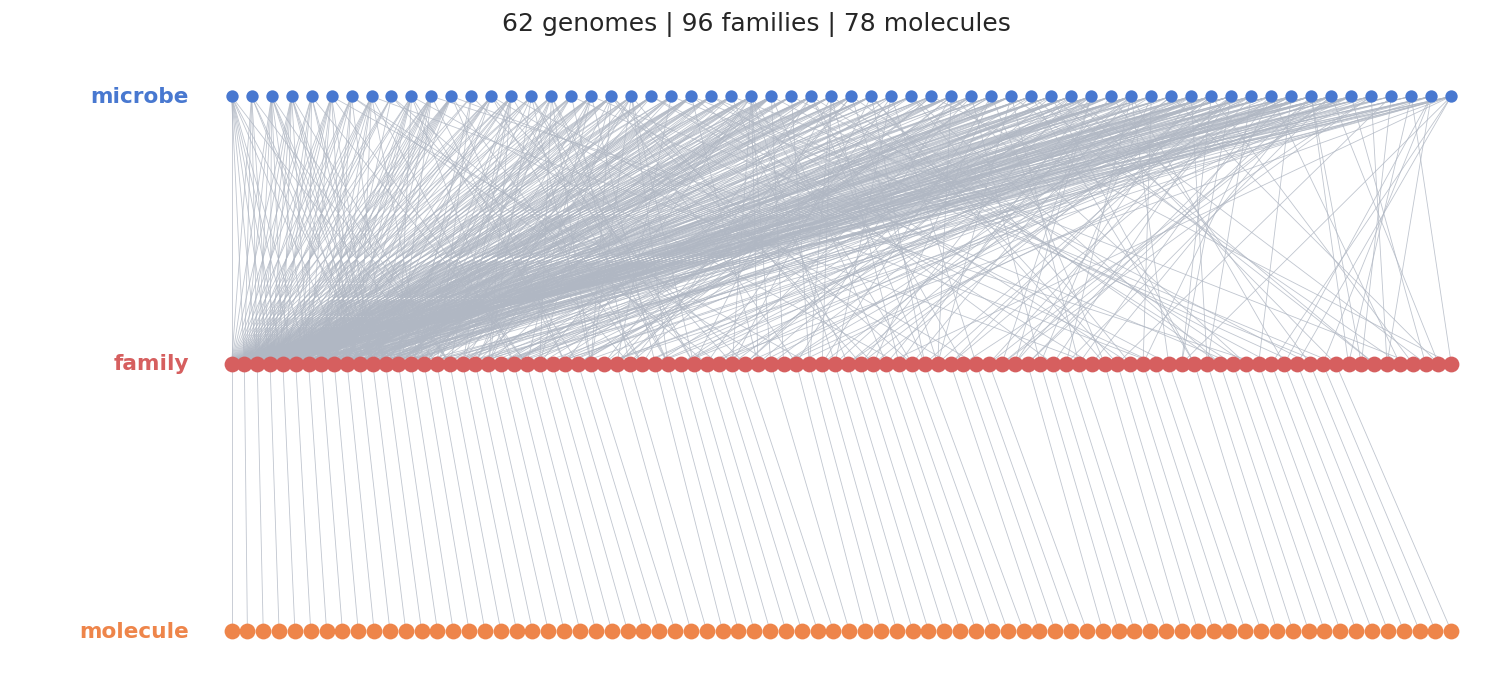

In [9]:
pos = layered_pos(G_truth, TRUTH_ROWS, anchor="family")
fig, ax = plt.subplots(figsize=(16, 7))
draw_layered(G_truth, pos, ax, {"family": 90, "microbe": 55, "molecule": 90}, TRUTH_ROWS)
n_by = Counter(d["ntype"] for _, d in G_truth.nodes(data=True))
ax.set_title(f"{n_by['microbe']} genomes | {n_by['family']} families | "
             f"{n_by['molecule']} molecules", fontsize=15)
save_fig(fig, "part5_ground_truth_graph", edge_frame(G_truth, pos))
plt.show()

### A readable slice

The full graph shows scale but not detail. Here are `N_SUBSET_STRAINS` genomes with every family
they carry and every molecule those families make, small enough to label.

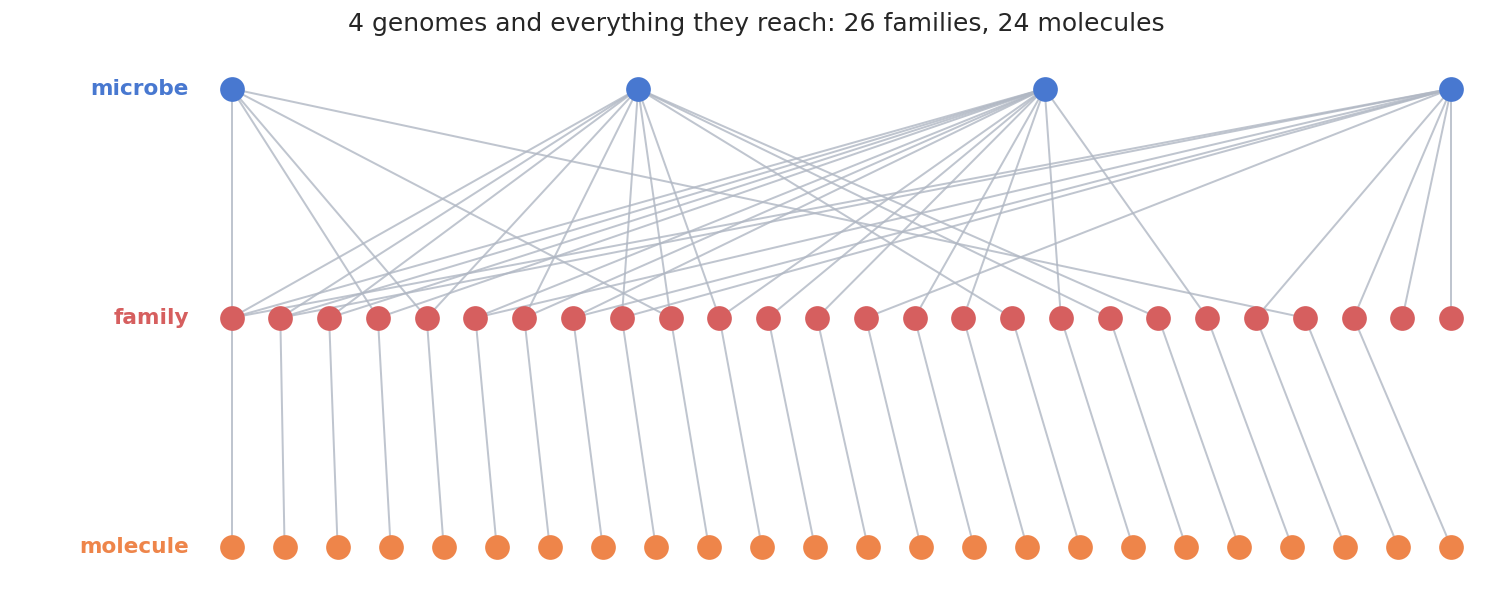

genomes shown:
  Streptomyces Unknown NBC_01217 [GCF_035994185.1]
  Streptomyces Unknown NPDC046853 [GCF_040645155.1]
  Streptomyces Unknown SM8 [GCF_000299175.2]
  Streptomyces mutabilis NPDC058354 [GCF_042723675.1]


In [10]:
rng = np.random.default_rng(SUBSET_SEED)
all_microbes = sorted(n for n, d in G_truth.nodes(data=True) if d["ntype"] == "microbe")
picked = sorted(rng.choice(all_microbes, size=min(N_SUBSET_STRAINS, len(all_microbes)),
                           replace=False).tolist())

# keep the chosen genomes plus everything reachable from them; other genomes
# carrying the same families are deliberately excluded so the picture stays small
keep = set(picked)
for m in picked:
    for f in G_truth.neighbors(m):
        if G_truth.nodes[f]["ntype"] != "family":
            continue
        keep.add(f)
        keep.update(mol for mol in G_truth.neighbors(f)
                    if G_truth.nodes[mol]["ntype"] == "molecule")
H = G_truth.subgraph(keep).copy()

hpos = layered_pos(H, TRUTH_ROWS, anchor="family")
fig, ax = plt.subplots(figsize=(16, 6))
draw_layered(H, hpos, ax, {"family": 220, "microbe": 220, "molecule": 220},
             TRUTH_ROWS, edge_width=1.2)
n_by = Counter(d["ntype"] for _, d in H.nodes(data=True))
ax.set_title(f"{n_by['microbe']} genomes and everything they reach: "
             f"{n_by['family']} families, {n_by['molecule']} molecules", fontsize=15)
save_fig(fig, "part5_ground_truth_graph_subset", edge_frame(H, hpos))
plt.show()

print("genomes shown:")
for m in picked:
    print(" ", m)

### The masked graph

Same data, one edge type removed. **Microbes move to the middle row**, because after masking both
edge types touch a microbe: it carries families above and produces molecules below.

The difficulty is visible directly. A molecule at the bottom connects up to several genomes, each
carrying several families. The responsible family must be one that *all* of those genomes carry.

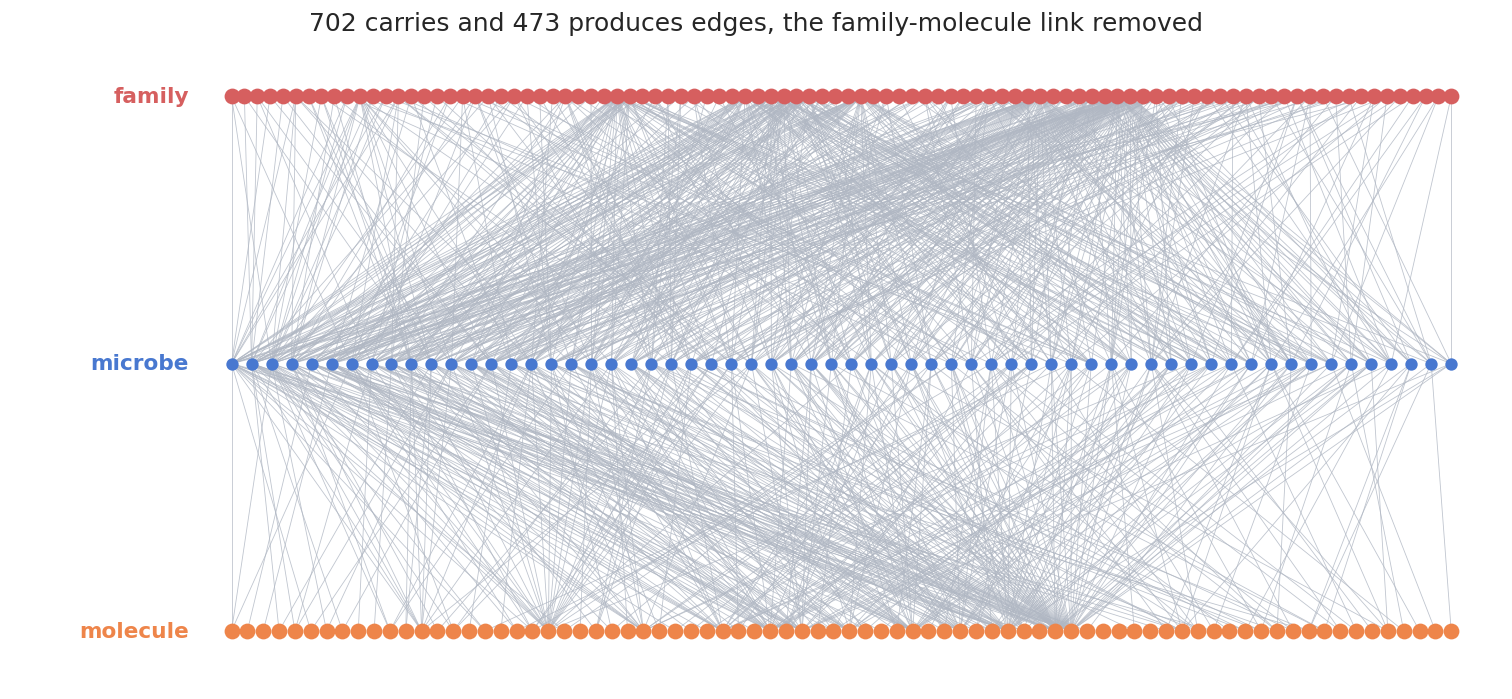

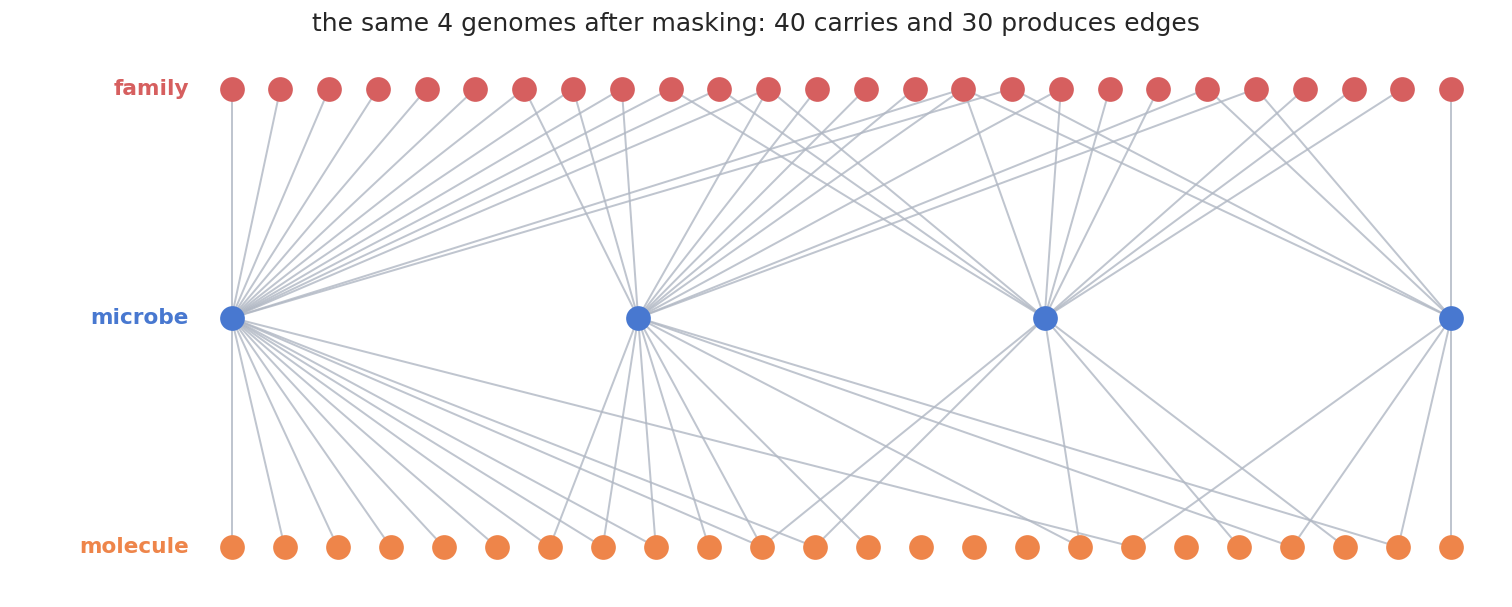

In [11]:
pos_m = layered_pos(G_masked, MASKED_ROWS, anchor="microbe")
fig, ax = plt.subplots(figsize=(16, 7))
draw_layered(G_masked, pos_m, ax, {"family": 90, "microbe": 55, "molecule": 90}, MASKED_ROWS)
e_by = Counter(d["etype"] for *_, d in G_masked.edges(data=True))
ax.set_title(f"{e_by['carries']} carries and {e_by['produces']} produces edges, "
             f"the family-molecule link removed", fontsize=15)
save_fig(fig, "part5_masked_graph", edge_frame(G_masked, pos_m))
plt.show()

# the same genomes as the ground-truth slice, so the two figures can be read
# side by side; the node set is identical because a genome produces exactly the
# molecules made by the families it carries
Hm = G_masked.subgraph(keep).copy()
hmpos = layered_pos(Hm, MASKED_ROWS, anchor="microbe")
fig, ax = plt.subplots(figsize=(16, 6))
draw_layered(Hm, hmpos, ax, {"family": 220, "microbe": 220, "molecule": 220},
             MASKED_ROWS, edge_width=1.2)
e_by = Counter(d["etype"] for *_, d in Hm.edges(data=True))
ax.set_title(f"the same {N_SUBSET_STRAINS} genomes after masking: "
             f"{e_by['carries']} carries and {e_by['produces']} produces edges", fontsize=15)
save_fig(fig, "part5_masked_graph_subset", edge_frame(Hm, hmpos))
plt.show()

### Presence/absence heatmap

Rows are genomes, ordered by hierarchical clustering of their family profile so that genomes with
similar repertoires sit together. Columns split into families on the left and molecules on the
right.

Columns lit in only a scattered subset of rows are the informative ones. A family present in
almost every genome carries little discriminative power precisely *because* it is everywhere — it
survives every intersection and so never rules anything out.

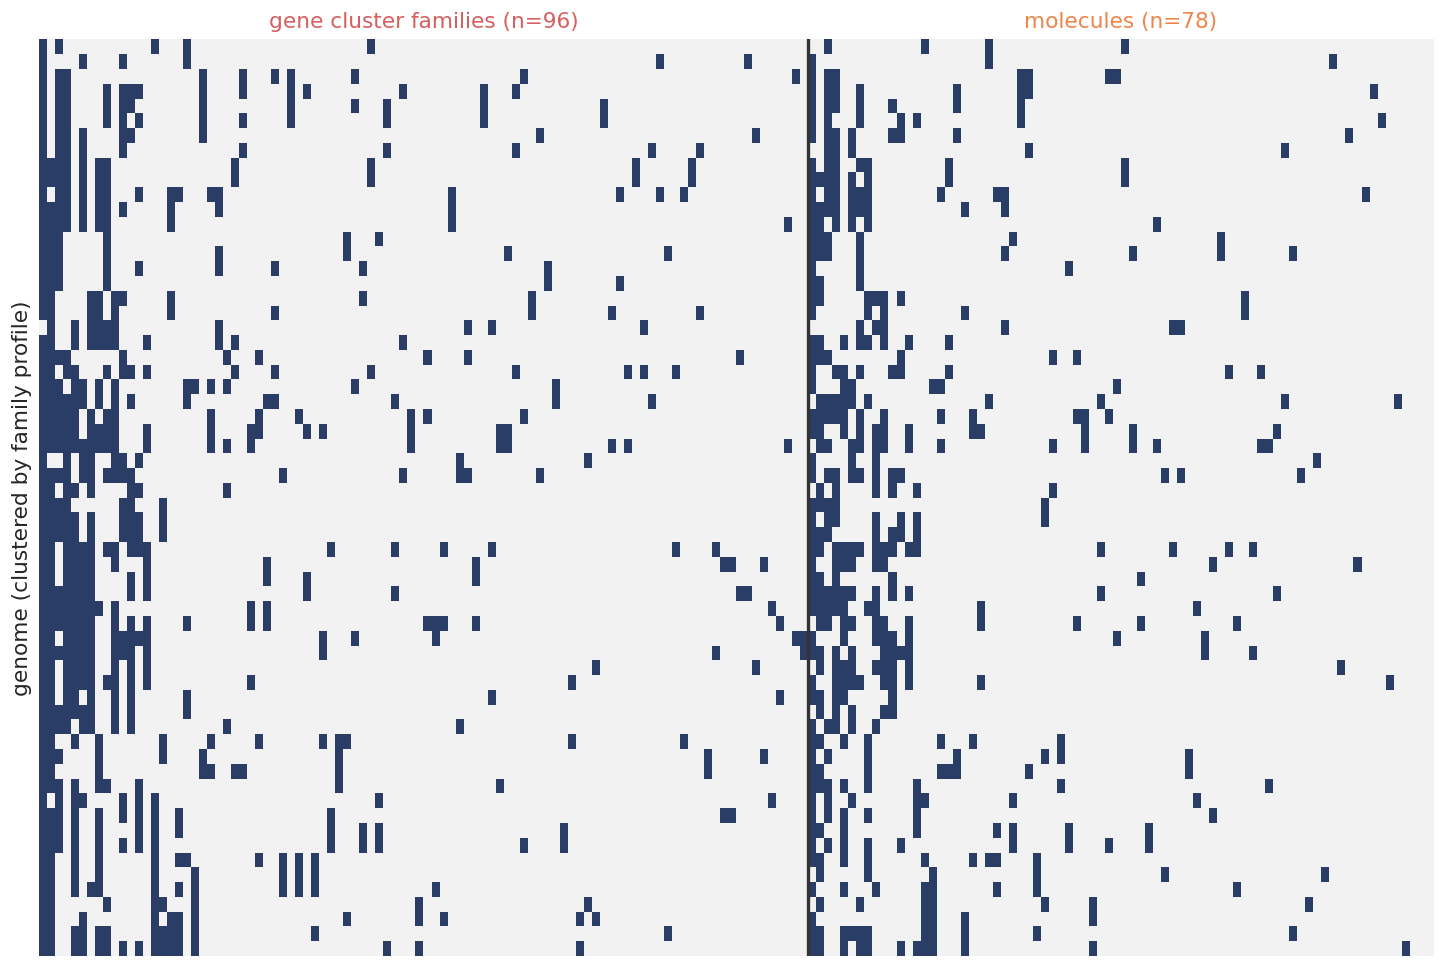

In [12]:
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import pdist

microbes = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "microbe")
families = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "family")
molecules = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "molecule")

gf = pd.DataFrame(0, index=microbes, columns=families, dtype=int)
gm = pd.DataFrame(0, index=microbes, columns=molecules, dtype=int)
for m in microbes:
    for nb in G_masked.neighbors(m):
        t = G_masked.nodes[nb]["ntype"]
        if t == "family":
            gf.loc[m, nb] = 1
        elif t == "molecule":
            gm.loc[m, nb] = 1

if len(gf) > 2:
    order = gf.index[leaves_list(linkage(pdist(gf.values, "jaccard"), "average"))]
else:
    order = gf.index
gf = gf.loc[order, gf.sum().sort_values(ascending=False).index]
gm = gm.loc[order, gm.sum().sort_values(ascending=False).index] if gm.shape[1] else gm

combined = pd.concat([gf, gm], axis=1)
fig, ax = plt.subplots(figsize=(15, max(4, min(len(order) * 0.16, 12))))
sns.heatmap(combined, cmap=["#f2f2f2", "#2a3d66"], cbar=False, ax=ax,
            xticklabels=False, yticklabels=len(order) <= 60, linewidths=0)
ax.axvline(gf.shape[1], color="#333333", lw=2)
ax.text(gf.shape[1] / 2, -0.8, f"gene cluster families (n={gf.shape[1]})",
        ha="center", fontsize=13, color=COLORS["family"])
ax.text(gf.shape[1] + gm.shape[1] / 2, -0.8, f"molecules (n={gm.shape[1]})",
        ha="center", fontsize=13, color=COLORS["molecule"])
ax.set_ylabel("genome (clustered by family profile)", fontsize=13)
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=6, left=False)
save_fig(fig, "part5_presence_absence_heatmap", combined.reset_index(names="genome"))
plt.show()

## 6. Node features

Optional per-node attributes for the score function of later notebooks, written to
`data/dataset1_streptomyces/node_features.csv` beside the two graphs, since it is an input for
those notebooks rather
than a figure.
BGC size comes from the antiSMASH-DB region coordinates, taken as the median over the regions
forming the family and ignoring clusters that run off the end of a contig, whose length is only a
lower bound.

Molecule size is not in the antiSMASH-DB response, which carries a compound *name* and no formula.
It comes instead from MIBiG's bulk metadata, a one megabyte download cached beside the other raw
data. Each family node *is* a MIBiG accession, so the join is exact, and we count **heavy atoms**
from the molecular formula — every atom except hydrogen — which is a robust size measure that needs
no chemistry library. Entries naming several compounds contribute their median.

Both columns together are what the size prior of notebook 02 consumes. If the download is
unavailable the molecule column is left empty and everything else still works.

In [13]:
import re
import tarfile


def heavy_atoms(formula):
    # every atom except hydrogen, e.g. C19H22O6 -> 19 + 6 = 25
    n = 0
    for element, count in re.findall(r"([A-Z][a-z]?)(\d*)", str(formula)):
        if element and element != "H":
            n += int(count) if count else 1
    return n or None


FORMULA_RE = re.compile(r"^(?:[A-Z][a-z]?\d*)+$")
SMILES_RE = re.compile(r"^[A-Za-z0-9@+\-\[\]()=#$%/\\.]{6,}$")


def heavy_atoms_smiles(smiles):
    # fallback for entries with a structure but no formula; bracketed atoms
    # count once each, then the organic subset outside brackets
    n = 0

    def take(m):
        nonlocal n
        sym = re.match(r"\d*([A-Za-z][a-z]?)", m.group(1))
        if sym and sym.group(1) != "H":
            n += 1
        return " "

    rest = re.sub(r"\[([^\]]*)\]", take, str(smiles))
    n += len(re.findall(r"Cl|Br|[BCNOSPFIbcnosp]", rest))
    return n or None


def find_structures(obj):
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            kl = str(k).lower()
            if isinstance(v, str) and ("struct" in kl or "smiles" in kl) \
                    and SMILES_RE.match(v.strip()) and "formula" not in kl:
                out.append(v.strip())
            else:
                out += find_structures(v)
    elif isinstance(obj, list):
        for v in obj:
            out += find_structures(v)
    return out


def find_formulas(obj):
    # the MIBiG schema moved between major versions, so rather than assume a
    # path we collect every value under a key mentioning "formula" that looks
    # like one. Robust to compounds living under "cluster", at the top level,
    # or nested inside a structure object.
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if "formula" in str(k).lower() and isinstance(v, str) \
                    and FORMULA_RE.match(v.strip()):
                out.append(v.strip())
            else:
                out += find_formulas(v)
    elif isinstance(obj, list):
        for v in obj:
            out += find_formulas(v)
    return out


def mibig_sizes():
    # accession (without version) -> median heavy-atom count of its compounds
    if MIBIG_JSON_URL is None:
        return {}
    if not MIBIG_TAR.exists():
        import requests
        r = requests.get(MIBIG_JSON_URL, timeout=300)
        r.raise_for_status()
        MIBIG_TAR.write_bytes(r.content)
        print(f"downloaded {MIBIG_TAR.name} ({len(r.content) / 1e6:.1f} MB)")
    sizes, sample = {}, None
    seen, from_smiles = set(), set()
    with tarfile.open(MIBIG_TAR, "r:*") as tar:
        for member in tar.getmembers():
            if not member.name.endswith(".json"):
                continue
            acc = Path(member.name).stem.split(".")[0]
            if not acc.startswith("BGC"):
                continue
            try:
                entry = json.loads(tar.extractfile(member).read())
            except Exception:
                continue
            sample = sample or entry
            seen.add(acc)
            vals = [h for f in find_formulas(entry) if (h := heavy_atoms(f)) is not None]
            if not vals:                      # no formula, try the structure
                vals = [h for sm in find_structures(entry)
                        if (h := heavy_atoms_smiles(sm)) is not None]
                if vals:
                    from_smiles.add(acc)
            if vals:
                sizes[acc] = int(np.median(vals))
    if sizes:
        print(f"MIBiG: {len(seen):,} entries read, {len(sizes):,} with a size "
              f"({len(from_smiles):,} of them from the structure rather than a formula)")
    elif sample is not None:
        # the schema changed in a way the search above does not cover
        print("no sizes found. top-level keys of one entry:", sorted(sample)[:12])
    globals()["MIBIG_SEEN"] = seen
    return sizes


MIBIG_SEEN = set()
try:
    ACC_SIZE = mibig_sizes()
except Exception as exc:
    ACC_SIZE = {}
    print(f"MIBiG metadata unavailable ({type(exc).__name__}); "
          f"molecule sizes will be empty")

# a molecule inherits the size of the MIBiG entry of the family that makes it
mol_size, no_entry, no_size = {}, 0, 0
for n, d in G_truth.nodes(data=True):
    if d["ntype"] != "molecule":
        continue
    accs = [str(f).split(".")[0] for f in G_truth.neighbors(n)
            if G_truth.nodes[f]["ntype"] == "family"]
    vals = [ACC_SIZE[a] for a in accs if a in ACC_SIZE]
    if vals:
        mol_size[n] = int(np.median(vals))
    elif ACC_SIZE and not any(a in MIBIG_SEEN for a in accs):
        no_entry += 1            # accession absent from the MIBiG release
    else:
        no_size += 1             # entry present but carries no structure at all
if no_entry or no_size:
    print(f"missing sizes: {no_entry} molecules whose accession is not in the MIBiG "
          f"release, {no_size} whose entry has neither formula nor structure")

rows = []
for n, d in sorted(G_truth.nodes(data=True), key=lambda x: (x[1]["ntype"], str(x[0]))):
    if d["ntype"] == "family":
        rows.append({"node": n, "ntype": "family",
                     "size": d.get("size_bp"), "unit": "bp",
                     "n_regions": d.get("n_regions"),
                     "bgc_class": d.get("bgc_class"), "label": d.get("label")})
    elif d["ntype"] == "molecule":
        rows.append({"node": n, "ntype": "molecule",
                     "size": mol_size.get(n), "unit": "heavy_atoms",
                     "n_regions": None, "bgc_class": None, "label": n})
features = pd.DataFrame(rows)

FEAT_CSV = DATA_DIR / "node_features.csv"
features.to_csv(FEAT_CSV, index=False)

fam = features.query("ntype == 'family'")
print(f"BGC sizes available for {fam['size'].notna().sum()} of {len(fam)} families")
print(f"  median {fam['size'].median():,.0f} bp, "
      f"range {fam['size'].min():,.0f}-{fam['size'].max():,.0f} bp")
mol = features.query("ntype == 'molecule'")
print(f"molecule sizes available for {mol['size'].notna().sum()} of {len(mol)} molecules")
if mol["size"].notna().any():
    print(f"  median {mol['size'].median():,.0f} heavy atoms, "
          f"range {mol['size'].min():,.0f}-{mol['size'].max():,.0f}")
print(f"\nwrote {FEAT_CSV.name}")
features.head()

MIBiG: 3,013 entries read, 2,498 with a size (592 of them from the structure rather than a formula)
missing sizes: 0 molecules whose accession is not in the MIBiG release, 13 whose entry has neither formula nor structure
BGC sizes available for 94 of 96 families
  median 46,396 bp, range 10,375-244,508 bp
molecule sizes available for 65 of 78 molecules
  median 28 heavy atoms, range 6-151

wrote node_features.csv


,node,ntype,size,unit,n_regions,bgc_class,label
0,BGC0000001.5,family,97709.0,bp,1.0,nrp-metallophore - nrps - t1pks hybrid,BGC0000001.5
1,BGC0000034.5,family,244508.0,bp,2.0,lanthipeptide-class-ii - lanthipeptide-class-i...,BGC0000034.5 (candicidin)
2,BGC0000040.5,family,124550.0,bp,1.0,azole-containing-ripp - nrps-like - t1pks hybrid,BGC0000040.5 (concanamycin A)
3,BGC0000065.5,family,41041.0,bp,2.0,pks-like,BGC0000065.5
4,BGC0000140.5,family,71262.0,bp,4.0,azole-containing-ripp - butyrolactone - pks-li...,BGC0000140.5


## Summary

Every hard fact this notebook establishes, written to one small text file so the numbers quoted
elsewhere can be checked without rerunning anything. Build-time facts are read back from the graph
metadata, so the file is correct on the load path too.

In [14]:
gmeta = G_truth.graph
mmeta = G_masked.graph
n_by = Counter(d["ntype"] for _, d in G_truth.nodes(data=True))
e_truth = Counter(d["etype"] for *_, d in G_truth.edges(data=True))
e_mask = Counter(d["etype"] for *_, d in G_masked.edges(data=True))

fams_of = {n: {v for v in G_masked.neighbors(n)
               if G_masked.nodes[v]["ntype"] == "family"}
           for n, d in G_masked.nodes(data=True) if d["ntype"] == "microbe"}
prod_of = {n: {v for v in G_masked.neighbors(n)
               if G_masked.nodes[v]["ntype"] == "microbe"}
           for n, d in G_masked.nodes(data=True) if d["ntype"] == "molecule"}
cand = {m: (set.intersection(*(fams_of[x] for x in P)) if P else set())
        for m, P in prod_of.items()}
sizes = sorted(len(v) for v in cand.values())
fams_per_mol = Counter(
    sum(1 for nb in G_truth.neighbors(n) if G_truth.nodes[nb]["ntype"] == "family")
    for n, d in G_truth.nodes(data=True) if d["ntype"] == "molecule")

n_before = mmeta.get("n_observations_before_silencing", e_mask["produces"])
rows = [
    ("SOURCE", ""),
    ("genus", gmeta.get("genus")),
    ("antiSMASH-DB regions downloaded", gmeta.get("n_regions")),
    ("regions with a MIBiG hit", gmeta.get("n_regions_with_hit")),
    ("", ""),
    ("CONFIGURATION", ""),
    ("family grouping threshold (%)", gmeta.get("family_sim_min")),
    ("compound label threshold (%)", gmeta.get("min_mibig_similarity")),
    ("minimum genomes per family", gmeta.get("min_genomes_per_family")),
    ("enforce injectivity", gmeta.get("enforce_injectivity")),
    ("families merged by injectivity", gmeta.get("n_families_merged")),
    ("silent rate", mmeta.get("silent_rate")),
    ("mask seed", mmeta.get("mask_seed")),
    ("", ""),
    ("GROUND-TRUTH GRAPH", ""),
    ("strains (N_s)", n_by["microbe"]),
    ("BGCs (N_b)", n_by["family"]),
    ("metabolites (N_m)", n_by["molecule"]),
    ("strain-BGC links", e_truth["carries"]),
    ("BGC-metabolite links (the answers)", e_truth["produces"]),
    ("metabolites with more than one BGC",
     sum(v for k, v in fams_per_mol.items() if k > 1)),
    ("BGCs per metabolite (distribution)", dict(sorted(fams_per_mol.items()))),
    ("", ""),
    ("MASKED GRAPH", ""),
    ("observations before silencing", n_before),
    ("strain-metabolite links kept", e_mask["produces"]),
    ("observations silenced", n_before - e_mask["produces"]),
    ("metabolites left without a producer",
     sum(1 for m, P in prod_of.items() if not P)),
    ("", ""),
    ("DIFFICULTY", ""),
    ("candidate BGCs per metabolite (median)", sizes[len(sizes) // 2] if sizes else 0),
    ("candidate BGCs per metabolite (range)",
     f"{min(sizes)}-{max(sizes)}" if sizes else "-"),
    ("metabolites with exactly one candidate", sum(1 for v in sizes if v == 1)),
    ("metabolites with no candidate", sum(1 for v in sizes if v == 0)),
]

SUMMARY_TXT = OUT_DIR / "summary.txt"
text = "notebook 01 - preprocessing summary\n" + "=" * 62 + "\n"
text += "\n".join("" if not k else (k if v == "" else f"{k:<44}{v}")
                    for k, v in rows) + "\n"
SUMMARY_TXT.write_text(text)
WRITTEN.append(SUMMARY_TXT)
print(text)

notebook 01 - preprocessing summary
SOURCE
genus                                       Streptomyces
antiSMASH-DB regions downloaded             2000
regions with a MIBiG hit                    1756

CONFIGURATION
family grouping threshold (%)               30
compound label threshold (%)                60
minimum genomes per family                  2
enforce injectivity                         True
families merged by injectivity              7
silent rate                                 0.3
mask seed                                   0

GROUND-TRUTH GRAPH
strains (N_s)                               62
BGCs (N_b)                                  96
metabolites (N_m)                           78
strain-BGC links                            702
BGC-metabolite links (the answers)          78
metabolites with more than one BGC          0
BGCs per metabolite (distribution)          {1: 78}

MASKED GRAPH
observations before silencing               650
strain-metabolite links kept              

## Done

In [15]:
# the two graph files in data/ are committed to the repository, so remember to
# add them after a rebuild; everything under output/ is regenerated locally
print("data files (tracked by git):")
for p in (TRUTH_JSON, MASKED_JSON, FEAT_CSV):
    print(f"  {p.relative_to(REPO_ROOT)}")
print(f"\nfigures and tables ({len(WRITTEN)} files):")
for p in WRITTEN:
    print(f"  {p.relative_to(REPO_ROOT)}")

data files (tracked by git):
  data/dataset1_streptomyces/ground_truth_metabologenomics_graph.json
  data/dataset1_streptomyces/masked_metabologenomics_graph.json
  data/dataset1_streptomyces/node_features.csv

figures and tables (16 files):
  output/01_streptomyces_preprocess_data/part5_ground_truth_graph.jpg
  output/01_streptomyces_preprocess_data/part5_ground_truth_graph.pdf
  output/01_streptomyces_preprocess_data/part5_ground_truth_graph.csv
  output/01_streptomyces_preprocess_data/part5_ground_truth_graph_subset.jpg
  output/01_streptomyces_preprocess_data/part5_ground_truth_graph_subset.pdf
  output/01_streptomyces_preprocess_data/part5_ground_truth_graph_subset.csv
  output/01_streptomyces_preprocess_data/part5_masked_graph.jpg
  output/01_streptomyces_preprocess_data/part5_masked_graph.pdf
  output/01_streptomyces_preprocess_data/part5_masked_graph.csv
  output/01_streptomyces_preprocess_data/part5_masked_graph_subset.jpg
  output/01_streptomyces_preprocess_data/part5_masked_

Later notebooks load the **masked** graph, reconstruct the candidate sets, and search for
assignments consistent with all of them at once. The ground-truth graph is used only for scoring,
and never as an input.

**One thing to keep in mind when reading the results.** In this dataset the molecule labels were
derived *from* the families, through MIBiG homology. Masking therefore removes an edge whose
evidence partly remains in how the families were defined, which makes the recovery task easier
than it would be in the field. It does not affect the method, and it disappears entirely with
laboratory data where sequencing and metabolomics are independent measurements — but the numbers
from this notebook should be read as a sanity check, not as a benchmark result.